# Realtime decoder — efficiency analysis (merged output)

Analyzes one run's **merged HDF5 output** (`<prefix>.rec_merged.h5` + `<prefix>.timings_merged.h5`)
for latency, encoder-growth scaling, and dropped/dumped-spike behavior.

**What this measures**

| Question | Where it's answered |
|---|---|
| End-to-end lag from spike acquisition to posterior, stage by stage | §1 |
| KDE cost as the encoding model grows (the growth question) | §2 |
| How many spikes got dumped, and how late they were | §3 |
| Decoder bin lag vs. real time over the session | §4 |
| One-table summary | §5 |

**Read these caveats first** (verified against source, branch `vinnie-hex-realtime`):

- `rec_3` (ENCODER_OUTPUT) has a **column-label rotation bug** (`encoder_process.py:333-336`
  labels vs `:544-554` write args): `sent_to_decoder`, `vel_thresh`, `frozen_model`, `task_state`,
  `nearby_spikes` are all shifted. The reliable sent-to-decoder indicator is **`cred_int >= 0`**.
- `DECODER_MISSED_SPIKES` (rec_5) is registered but **never written** (dead code) — per-spike
  lateness below is reconstructed from wall-clock timings instead.
- `rec_4.dropped_spikes` / `duplicated_spikes` are **cumulative counters**. The drop census runs
  once per 2000 received messages (decoder buffer wrap, `decoder_process.py:636-654`) and slightly
  **overcounts** (~2 bins' worth of in-flight spikes per wrap, never corrected).
- `rec_4.timestamp - bin_timestamp_r == delay_samples` **by construction** — it is the configured
  6 ms grace period, *not* backlog. Real staleness is computed in §4 via a sample→wall clock fit.
- Dropping is decoder-side only: dumped spikes are **never removed from the encoding clouds**.


In [1]:
import gc, glob, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import oyaml as yaml

# ---- palette / chart chrome (validated reference palette, light mode) ----
PAL   = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
         '#e87ba4', '#008300', '#4a3aa7', '#e34948']   # fixed slot order
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURF, BASE = '#e1e0d9', '#fcfcfb', '#c3c2b7'

plt.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': BASE, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2.0, 'font.size': 10.5, 'axes.titlesize': 11.5,
    'legend.frameon': False, 'figure.dpi': 110,
})

def style_ax(ax):
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

def q(s, p):
    return float(np.nanpercentile(s, p))


In [2]:
# ---------------- run selection ----------------
RUN_DIR    = '/media/ssd1/decoder_output/Toby/20250316_07_r4'
RUN_PREFIX = None          # None -> newest *.rec_merged.h5 in RUN_DIR
EXPORT_CSV = True
WINDOW_S   = 60            # aggregation window (seconds) for time-series figures

if RUN_PREFIX is None:
    merged = sorted(glob.glob(os.path.join(RUN_DIR, '*.rec_merged.h5')))
    assert merged, f'no *.rec_merged.h5 in {RUN_DIR}'
    RUN_PREFIX = os.path.basename(merged[-1]).replace('.rec_merged.h5', '')

REC = os.path.join(RUN_DIR, RUN_PREFIX + '.rec_merged.h5')
TIM = os.path.join(RUN_DIR, RUN_PREFIX + '.timings_merged.h5')

cfg_path = glob.glob(os.path.join(RUN_DIR, RUN_PREFIX + '*.config.yaml'))[0]
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

FS          = cfg['sampling_rate']['spikes']                 # 30000
TBIN        = cfg['decoder']['time_bin']['samples']          # 180 -> 6 ms bins
DELAY       = cfg['decoder']['time_bin']['delay_samples']    # 180 -> 6 ms grace
DEC_BUFSIZE = cfg['decoder']['bufsize']                      # drop census period
ENC_BUFSIZE = cfg['encoder']['bufsize']                      # KDE saturation point
DEC_RANKS   = list(cfg['decoder_assignment'].keys())
TRODES      = sorted(t for ts in cfg['decoder_assignment'].values() for t in ts)

print(f'run     : {RUN_PREFIX}')
print(f'bins    : {TBIN} samples = {TBIN/FS*1e3:.1f} ms, delay {DELAY/FS*1e3:.1f} ms')
print(f'trodes  : {TRODES}  (decoder ranks {DEC_RANKS})')
print(f'bufsize : decoder {DEC_BUFSIZE:,}, encoder {ENC_BUFSIZE:,}')
print(f'train_all_task_states: {cfg["encoder"].get("train_all_task_states", False)}')


run     : 20260825_193823_Toby_hex_realtime_decoding
bins    : 180 samples = 6.0 ms, delay 6.0 ms
trodes  : [1, 3, 6, 9, 11, 14, 17, 20]  (decoder ranks [1])
bufsize : decoder 2,000, encoder 3,000,000
train_all_task_states: True


In [3]:
# ---------------- load (fixed-format HDF5 -> whole-key loads; slice then free) ----------------
spikes = pd.read_hdf(TIM, 'spikes').reset_index(drop=True)       # 1 row per sent-AND-received spike
post   = pd.read_hdf(TIM, 'posterior').reset_index(drop=True)    # 1 row per decoded 6 ms bin
post   = post.sort_values('bin_timestamp_l', ignore_index=True)

_r     = pd.read_hdf(TIM, 'ripples')                             # LFP clock: sample ts <-> wall ns
rips   = _r[['timestamp', 't_recv_data']].reset_index(drop=True)
del _r; gc.collect()

_r3  = pd.read_hdf(REC, 'rec_3')                                 # ENCODER_OUTPUT (wide!)
rec3 = _r3[['timestamp', 'elec_grp_id', 'encode_spike', 'cred_int']].copy()
del _r3; gc.collect()
rec3['sent'] = rec3.cred_int >= 0        # label-rotation bug: do NOT use 'sent_to_decoder'

_r4  = pd.read_hdf(REC, 'rec_4')                                 # DECODER_OUTPUT (wide!)
rec4 = _r4[['timestamp', 'bin_timestamp_l', 'bin_timestamp_r', 'spike_count',
            'dropped_spikes', 'duplicated_spikes', 'cred_int_post',
            'task_state', 'velocity', 'dec_rank']].copy()
del _r4; gc.collect()
rec4 = rec4.sort_values('timestamp', ignore_index=True)

print(f'/spikes    {len(spikes):>12,} rows')
print(f'/posterior {len(post):>12,} rows')
print(f'/ripples   {len(rips):>12,} rows')
print(f'rec_3      {len(rec3):>12,} rows (amplitude-qualified spikes)')
print(f'rec_4      {len(rec4):>12,} rows (decoded bins)')


/spikes       1,319,569 rows
/posterior      199,044 rows
/ripples      1,791,401 rows
rec_3         1,422,988 rows (amplitude-qualified spikes)
rec_4           199,044 rows (decoded bins)


In [4]:
# ---------------- sample-clock <-> wall-clock bridge + sanity checks ----------------
# /ripples pairs the 30 kHz sample counter with client receive wall-ns at 1.5 kHz.
a, b = np.polyfit(rips.timestamp.to_numpy(float), rips.t_recv_data.to_numpy(float), 1)
def wall_of_ts(ts):
    """Estimated client wall-clock (ns) at Trodes sample count ts."""
    return a * np.asarray(ts, float) + b
resid_ms = (rips.t_recv_data - wall_of_ts(rips.timestamp)) / 1e6
print(f'clock fit: slope {a:.2f} ns/sample (ideal {1e9/FS:.2f});'
      f' residual p50 {q(resid_ms,50):.2f} ms, p99 {q(resid_ms,99):.2f} ms')

T0 = float(rips.t_recv_data.min())          # session wall-clock origin
def t_min(ns):
    """Session time in minutes for wall-ns values."""
    return (np.asarray(ns, float) - T0) / 60e9

checks = []
delta = (rec4.timestamp - rec4.bin_timestamp_r).unique()
checks.append(('rec_4 rows == /posterior rows', len(rec4) == len(post),
               f'{len(rec4):,} vs {len(post):,}'))
checks.append(('timestamp - bin_r == DELAY (by construction)',
               list(delta) == [DELAY], f'{delta}'))
n_sent = int(rec3.sent.sum())
checks.append(('rec_3 sent (cred_int>=0) ~ /spikes rows', abs(n_sent - len(spikes)) < 100,
               f'{n_sent:,} sent vs {len(spikes):,} received '
               f'({n_sent - len(spikes)} sent-never-received)'))
tiling = np.diff(post.bin_timestamp_l.to_numpy())
checks.append(('bins tile contiguously at TBIN', (tiling == TBIN).mean() > 0.999,
               f'{(tiling != TBIN).sum()} gaps of {len(tiling)} steps'))
print()
for name, ok, detail in checks:
    print(f'  [{"OK " if ok else "!!"}] {name}: {detail}')


clock fit: slope 44725.82 ns/sample (ideal 33333.33); residual p50 14089.11 ms, p99 121404.46 ms

  [OK ] rec_4 rows == /posterior rows: 199,044 vs 199,044
  [OK ] timestamp - bin_r == DELAY (by construction): [180]
  [OK ] rec_3 sent (cred_int>=0) ~ /spikes rows: 1,319,576 sent vs 1,319,569 received (7 sent-never-received)
  [OK ] bins tile contiguously at TBIN: 61 gaps of 199043 steps


In [5]:
# ---------------- spike -> bin join, stage latencies ----------------
bl = post.bin_timestamp_l.to_numpy()
br = post.bin_timestamp_r.to_numpy()
ts = spikes.timestamp.to_numpy()

idx = np.searchsorted(bl, ts, side='right') - 1
in_bin = (idx >= 0) & (ts < br[np.clip(idx, 0, None)])
spikes['bin_idx'] = np.where(in_bin, idx, -1)
n_unassigned = int((~in_bin).sum())

sp = spikes[spikes.bin_idx >= 0].copy()
sp['t_start_post'] = post.t_start_post.to_numpy()[sp.bin_idx]
sp['t_end_post']   = post.t_end_post.to_numpy()[sp.bin_idx]

# stage latencies in ms
sp['lat_delivery'] = (sp.t_recv_data - sp.t_send_data) / 1e6   # CROSS-CLOCK (recording pc -> client)
sp['lat_encq']     = (sp.t_start_kde - sp.t_recv_data) / 1e6
sp['lat_kde']      = (sp.t_end_kde - sp.t_start_kde) / 1e6
sp['lat_send']     = (sp.t_end_enc_send - sp.t_start_enc_send) / 1e6
sp['lat_mpi']      = (sp.t_decoder - sp.t_end_enc_send) / 1e6
sp['lat_binwait']  = (sp.t_start_post - sp.t_decoder) / 1e6    # includes designed 6 ms delay
sp['lat_e2e']      = (sp.t_end_post - sp.t_recv_data) / 1e6    # pure client-clock end-to-end
sp['late']         = sp.t_decoder >= sp.t_start_post           # arrived after its bin was decoded

STAGES = ['lat_delivery', 'lat_encq', 'lat_kde', 'lat_send',
          'lat_mpi', 'lat_binwait', 'lat_e2e']
tbl = pd.DataFrame({s: {'p50': q(sp[s], 50), 'p95': q(sp[s], 95), 'p99': q(sp[s], 99)}
                    for s in STAGES}).T.round(3)
tbl.columns = ['p50 (ms)', 'p95 (ms)', 'p99 (ms)']
print(f'spikes in no bin (LFP gaps / before first / after last): '
      f'{n_unassigned:,} ({n_unassigned/len(spikes)*100:.3f} %)')
print(f'late spikes (t_decoder >= t_start_post): {int(sp.late.sum()):,} '
      f'({sp.late.mean()*100:.2f} % of assigned)')
tbl


spikes in no bin (LFP gaps / before first / after last): 600,076 (45.475 %)
late spikes (t_decoder >= t_start_post): 202,116 (28.09 % of assigned)


,p50 (ms),p95 (ms),p99 (ms)
lat_delivery,4.918,6477.964,9203.429
lat_encq,0.054,0.082,0.105
lat_kde,4.638,11.705,19.640
lat_send,0.017,0.025,0.036
lat_mpi,0.006,0.027,0.258
lat_binwait,6.319,488765.971,609804.215
lat_e2e,8.288,488777.282,609818.555


## §1 — End-to-end and stage-wise latency

Per-spike wall-clock stages (all `time.time_ns()` on the MPI host except **delivery**, which mixes
the recording computer's clock and is shown for context only):

`delivery` (Trodes→client) → `encq` (encoder queue) → `kde` (joint-prob evaluation) →
`send` (MPI pack+send) → `mpi` (transit + decoder queue) → `binwait` (buffered until its
bin is decoded; includes the configured 6 ms delay) → **`e2e`** = spike receipt → posterior done.

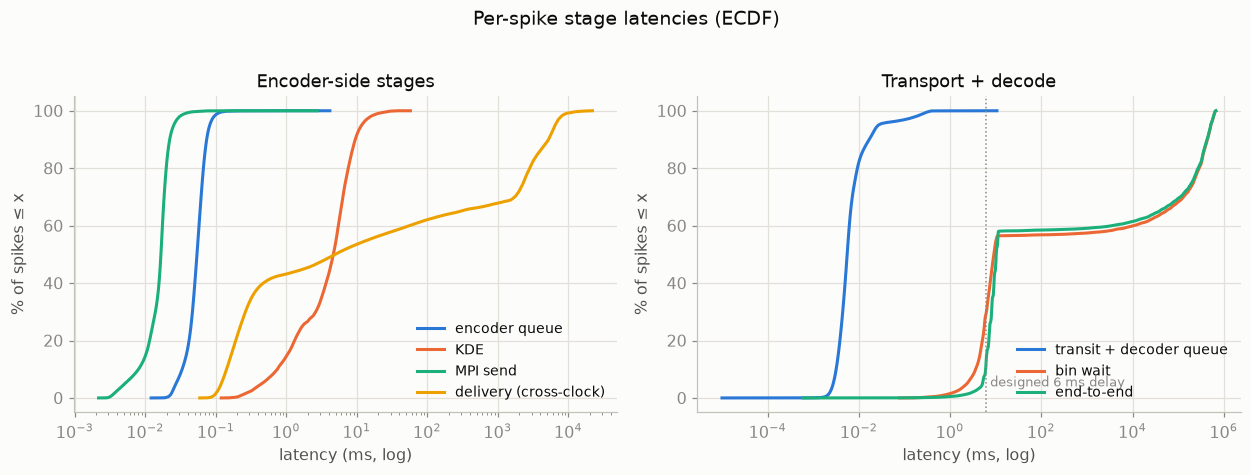

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
enc_stages = [('lat_encq', 'encoder queue'), ('lat_kde', 'KDE'),
              ('lat_send', 'MPI send'), ('lat_delivery', 'delivery (cross-clock)')]
dec_stages = [('lat_mpi', 'transit + decoder queue'),
              ('lat_binwait', 'bin wait'), ('lat_e2e', 'end-to-end')]

for ax, stages, title in ((axes[0], enc_stages, 'Encoder-side stages'),
                          (axes[1], dec_stages, 'Transport + decode')):
    for (col, label), c in zip(stages, PAL):
        v = np.sort(sp[col].to_numpy())
        v = v[v > 0]
        ax.plot(v, np.linspace(0, 100, v.size), color=c, label=label)
    ax.set_xscale('log')
    ax.set_xlabel('latency (ms, log)'); ax.set_ylabel('% of spikes ≤ x')
    ax.set_title(title); ax.legend(loc='lower right', fontsize=9)
    style_ax(ax)
axes[1].axvline(DELAY / FS * 1e3, color=MUTED, lw=1, ls=':')
axes[1].annotate('designed 6 ms delay', xy=(DELAY / FS * 1e3, 4),
                 xytext=(3, 0), textcoords='offset points', color=MUTED, fontsize=8.5)
fig.suptitle('Per-spike stage latencies (ECDF)', y=1.02)
fig.tight_layout(); plt.show()


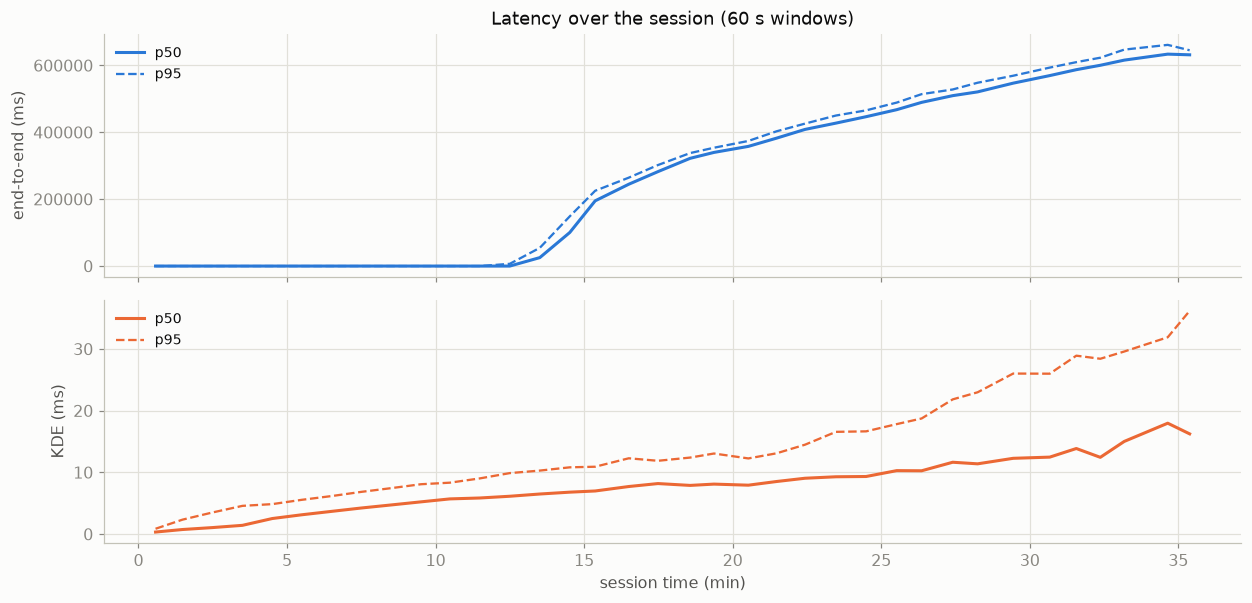

In [7]:
# latency drift over the session: windowed p50 / p95
sp['w'] = (t_min(sp.t_recv_data) * 60 // WINDOW_S).astype(int)
g = sp.groupby('w')
wm = pd.DataFrame({
    't': g.t_recv_data.median().pipe(t_min),
    'e2e_p50': g.lat_e2e.median(),   'e2e_p95': g.lat_e2e.quantile(0.95),
    'kde_p50': g.lat_kde.median(),   'kde_p95': g.lat_kde.quantile(0.95),
})

fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.6), sharex=True)
for ax, m, label, c in ((axes[0], 'e2e', 'end-to-end', PAL[0]),
                        (axes[1], 'kde', 'KDE', PAL[1])):
    ax.plot(wm.t, wm[f'{m}_p50'], color=c, label='p50')
    ax.plot(wm.t, wm[f'{m}_p95'], color=c, ls='--', lw=1.5, label='p95')
    ax.set_ylabel(f'{label} (ms)'); ax.legend(loc='upper left', fontsize=9)
    style_ax(ax)
axes[1].set_xlabel('session time (min)')
axes[0].set_title(f'Latency over the session ({WINDOW_S} s windows)')
fig.tight_layout(); plt.show()


## §2 — KDE cost vs. encoding-model size (the growth question)

The encoding model for trode *t* is the mark cloud `marks[:mark_idx]`; `get_joint_prob`
evaluates a Gaussian kernel against **every stored mark** (capped at `encoder.bufsize`),
so per-spike KDE cost should grow ~linearly with model size. Model size over time is
reconstructed exactly as the cumulative sum of `rec_3.encode_spike` per trode, and
validated against the saved `*_trode_N.encoder.npz` `mark_idx`.

In [8]:
# ---------------- model-size reconstruction + validation ----------------
rec3 = rec3.sort_values('timestamp', ignore_index=True)
rec3['model_size'] = rec3.groupby('elec_grp_id').encode_spike.cumsum()

rows = []
for t in TRODES:
    f = os.path.join(RUN_DIR, f'{RUN_PREFIX}_trode_{t}.encoder.npz')
    npz_idx = int(np.load(f)['mark_idx'][0]) if os.path.exists(f) else None
    rec_idx = int(rec3.loc[rec3.elec_grp_id == t, 'model_size'].iloc[-1])
    rows.append({'trode': t, 'reconstructed': rec_idx, 'npz mark_idx': npz_idx,
                 'match': npz_idx is not None and rec_idx == npz_idx})
val = pd.DataFrame(rows).set_index('trode')
print(f'total encoding spikes: {int(rec3.encode_spike.sum()):,} '
      f'(encoder bufsize {ENC_BUFSIZE:,} — saturation {"NOT reached" if val.reconstructed.max() < ENC_BUFSIZE else "REACHED"})')
val


total encoding spikes: 744,218 (encoder bufsize 3,000,000 — saturation NOT reached)


,reconstructed,npz mark_idx,match
trode,,,
1,81024,81024,True
3,128783,128783,True
6,106555,106555,True
9,119288,119288,True
11,98355,98355,True
14,104966,104966,True
17,78137,78137,True
20,27110,27110,True


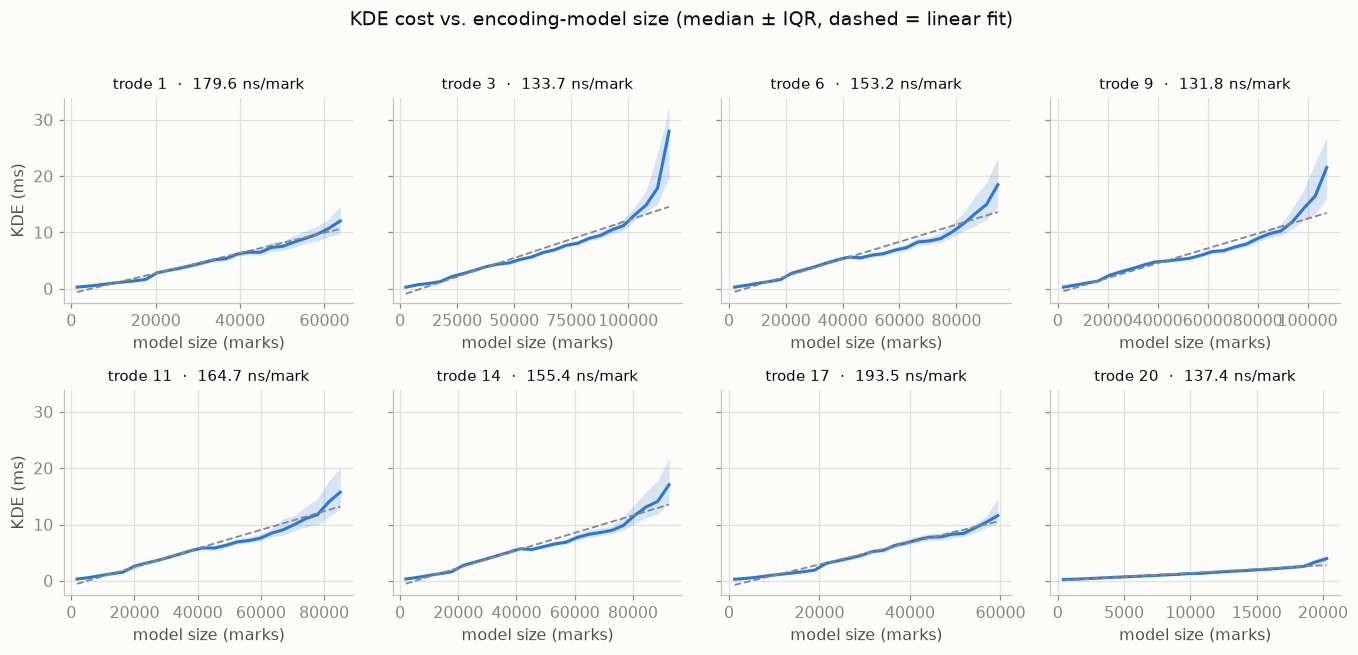

In [9]:
# attach model-size-at-spike-time to each timed spike (per-trode as-of join)
sp['model_size'] = 0
for t in TRODES:
    r3t = rec3[rec3.elec_grp_id == t]
    m = sp.elec_grp_id == t
    pos = np.searchsorted(r3t.timestamp.to_numpy(), sp.loc[m, 'timestamp'].to_numpy(),
                          side='right') - 1
    sizes = r3t.model_size.to_numpy()
    sp.loc[m, 'model_size'] = np.where(pos >= 0, sizes[np.clip(pos, 0, None)], 0)

fig, axes = plt.subplots(2, 4, figsize=(12.5, 5.8), sharey=True)
slopes = {}
for ax, t in zip(axes.ravel(), TRODES):
    d = sp[sp.elec_grp_id == t]
    bins = np.linspace(0, d.model_size.max() + 1, 25)
    gb = d.groupby(pd.cut(d.model_size, bins, labels=False), observed=True).lat_kde
    ctr = (bins[:-1] + bins[1:]) / 2
    med = gb.median().reindex(range(24))
    lo, hi = gb.quantile(0.25).reindex(range(24)), gb.quantile(0.75).reindex(range(24))
    ax.fill_between(ctr, lo, hi, color=PAL[0], alpha=0.18, lw=0)
    ax.plot(ctr, med, color=PAL[0])
    k = np.polyfit(d.model_size, d.lat_kde * 1e6, 1)[0]   # ns per mark
    slopes[t] = k
    ax.plot(ctr, np.polyval(np.polyfit(d.model_size, d.lat_kde, 1), ctr),
            color=MUTED, ls='--', lw=1.2)
    ax.set_title(f'trode {t}  ·  {k:.1f} ns/mark', fontsize=10)
    ax.set_xlabel('model size (marks)')
    style_ax(ax)
for ax in axes[:, 0]:
    ax.set_ylabel('KDE (ms)')
fig.suptitle('KDE cost vs. encoding-model size (median ± IQR, dashed = linear fit)', y=1.02)
fig.tight_layout(); plt.show()


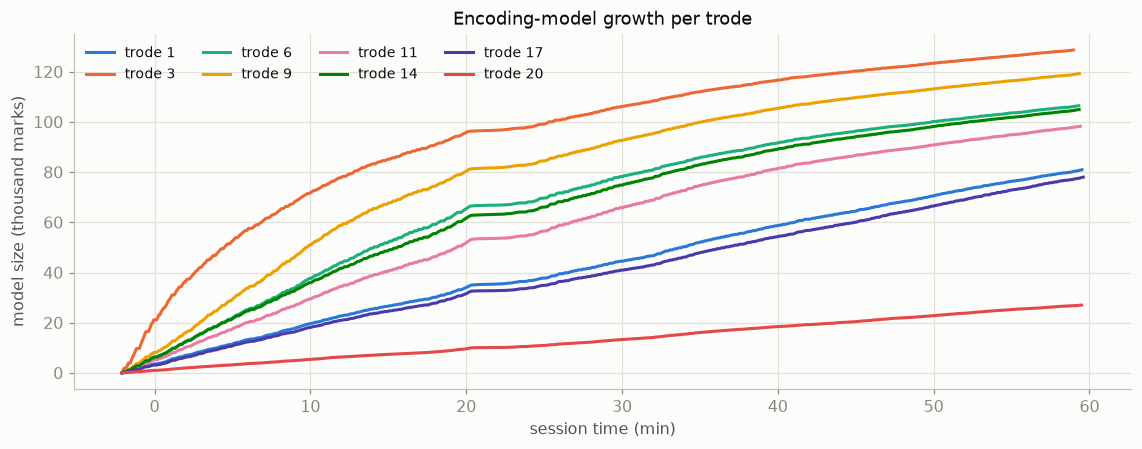

In [10]:
# model growth over the session (per trode)
fig, ax = plt.subplots(figsize=(10.5, 4.2))
r3s = rec3[rec3.sent].copy()          # spikes with a wall timestamp in /spikes are the sent ones;
wall_r3 = wall_of_ts(rec3.timestamp)  # use the sample->wall fit for ALL rec_3 rows instead
for t, c in zip(TRODES, PAL):
    m = (rec3.elec_grp_id == t).to_numpy()
    x = t_min(wall_r3[m][::200]); y = rec3.model_size.to_numpy()[m][::200] / 1e3
    ax.plot(x, y, color=c, label=f'trode {t}')
ax.set_xlabel('session time (min)'); ax.set_ylabel('model size (thousand marks)')
ax.set_title('Encoding-model growth per trode')
ax.legend(ncols=4, fontsize=9, loc='upper left')
style_ax(ax); fig.tight_layout(); plt.show()


## §3 — Dropped / dumped spike quantification

Dumping is passive: a spike whose likelihood message misses its bin's decode is simply never
selected into any bin and is overwritten in the 2000-slot circular buffer. The decoder counts
these once per buffer wrap into a **cumulative** `dropped_spikes`; timestamp-duplicate removal
is a separate discard path (`duplicated_spikes`). Since `DECODER_MISSED_SPIKES` was never
implemented, per-spike lateness here is reconstructed as `t_decoder − t_start_post` of the
spike's true bin — spikes right of 0 are the dumped population.

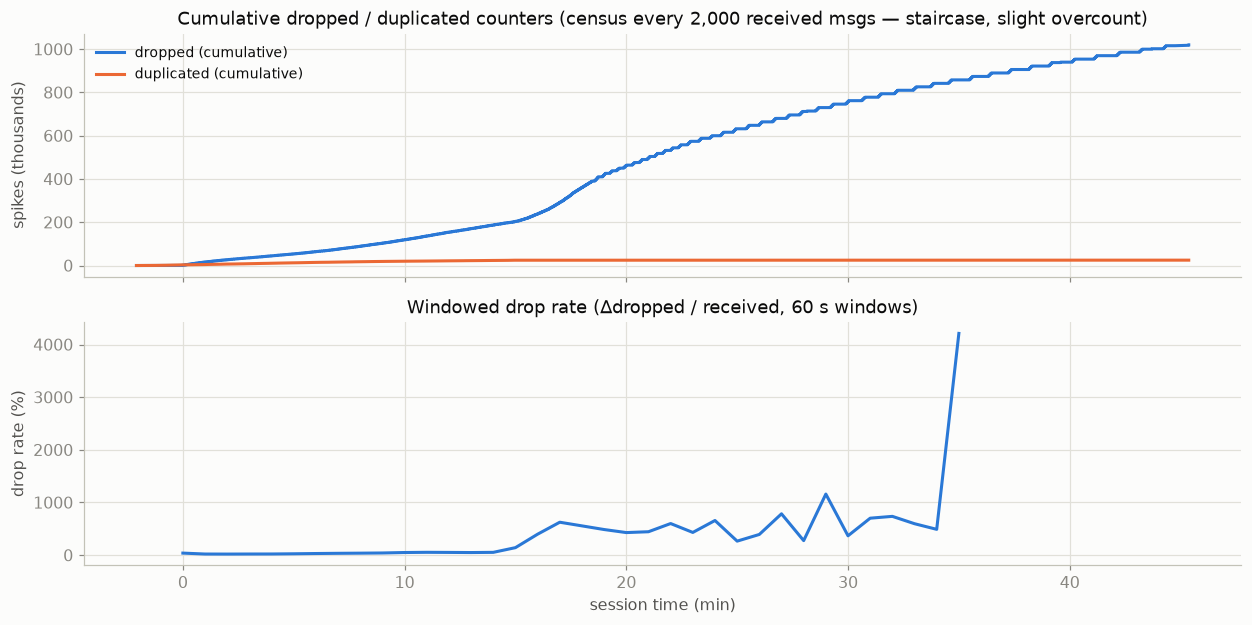

final counters: dropped 1,019,979   duplicated 24,795   of 1,319,569 received (77.3 % dropped)


In [11]:
# cumulative counters + windowed drop rate
rec4['t'] = t_min(wall_of_ts(rec4.timestamp))
fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.8), sharex=True)

axes[0].plot(rec4.t, rec4.dropped_spikes / 1e3, color=PAL[0], label='dropped (cumulative)')
axes[0].plot(rec4.t, rec4.duplicated_spikes / 1e3, color=PAL[1], label='duplicated (cumulative)')
axes[0].set_ylabel('spikes (thousands)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_title('Cumulative dropped / duplicated counters (census every '
                  f'{DEC_BUFSIZE:,} received msgs — staircase, slight overcount)')
style_ax(axes[0])

w4 = (rec4.t * 60 // WINDOW_S).astype(int)
dropped_w = rec4.groupby(w4).dropped_spikes.max().diff()
recv_w = sp.groupby((t_min(sp.t_decoder) * 60 // WINDOW_S).astype(int)).size()
rate = (dropped_w / recv_w.reindex(dropped_w.index)).mul(100)
axes[1].plot(dropped_w.index * WINDOW_S / 60, rate, color=PAL[0])
axes[1].set_ylabel('drop rate (%)'); axes[1].set_xlabel('session time (min)')
axes[1].set_title(f'Windowed drop rate (Δdropped / received, {WINDOW_S} s windows)')
style_ax(axes[1])
fig.tight_layout(); plt.show()

print(f'final counters: dropped {int(rec4.dropped_spikes.iloc[-1]):,}   '
      f'duplicated {int(rec4.duplicated_spikes.iloc[-1]):,}   '
      f'of {len(spikes):,} received '
      f'({rec4.dropped_spikes.iloc[-1]/len(spikes)*100:.1f} % dropped)')


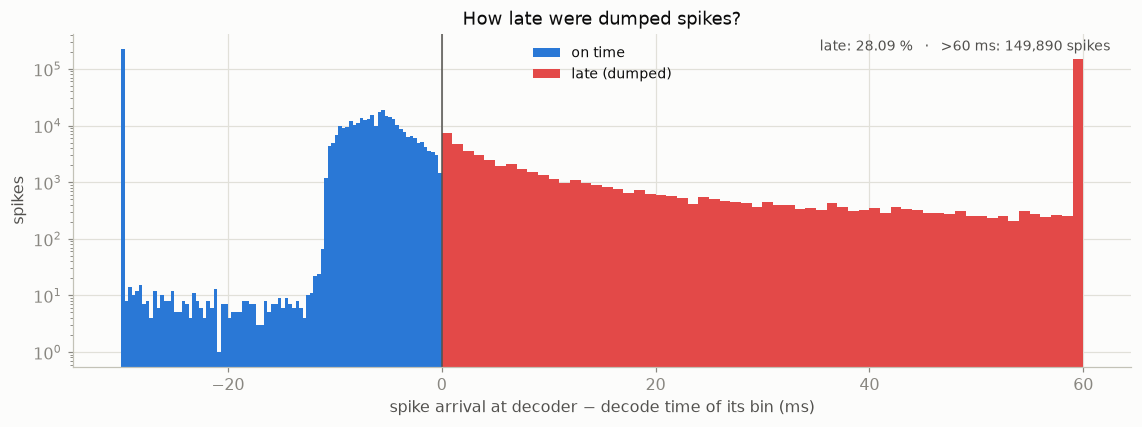

late-spike lateness quantiles (ms): {50: 2022.12, 95: 5711.51, 99: 6377.24}


In [12]:
# lateness distribution (the DECODER_MISSED_SPIKES substitute)
lateness = (sp.t_decoder - sp.t_start_post) / 1e6
CLIP = (-30, 60)
v = lateness.clip(*CLIP)
n_over = int((lateness > CLIP[1]).sum())

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.hist(v[v < 0],  bins=90, range=(CLIP[0], 0), color=PAL[0], label='on time')
ax.hist(v[v >= 0], bins=60, range=(0, CLIP[1]), color=PAL[7], label='late (dumped)')
ax.axvline(0, color=INK2, lw=1)
ax.set_xlabel('spike arrival at decoder − decode time of its bin (ms)')
ax.set_ylabel('spikes'); ax.set_yscale('log')
ax.set_title('How late were dumped spikes?')
ax.legend(fontsize=9)
ax.annotate(f'late: {sp.late.mean()*100:.2f} %   ·   >{CLIP[1]} ms: {n_over:,} spikes',
            xy=(0.98, 0.95), xycoords='axes fraction', ha='right', color=INK2, fontsize=9)
style_ax(ax); fig.tight_layout(); plt.show()
print('late-spike lateness quantiles (ms):',
      {p: round(q(lateness[lateness > 0], p), 2) for p in (50, 95, 99)})


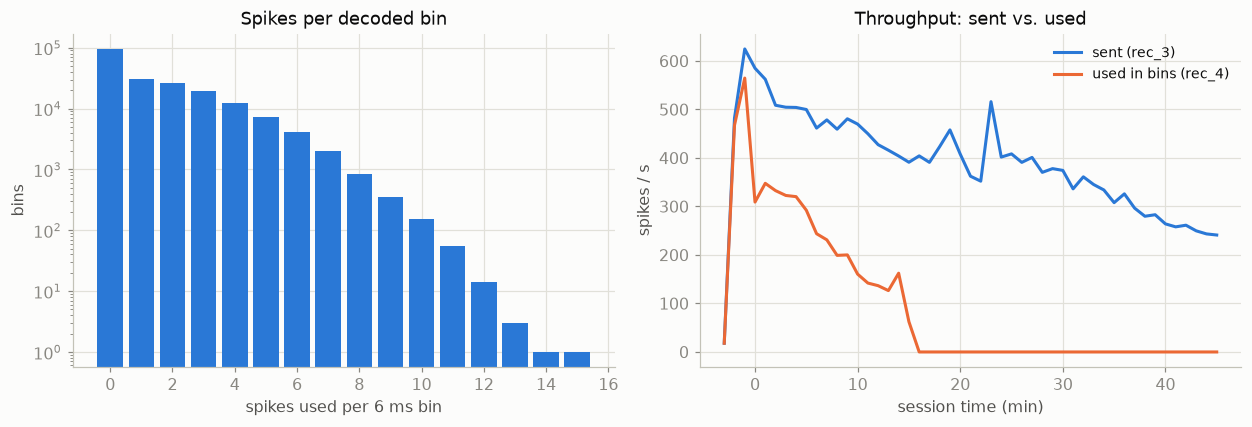

In [13]:
# spikes per bin: distribution + sent vs used over time
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

vc = rec4.spike_count.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=PAL[0], width=0.82)
axes[0].set_yscale('log')
axes[0].set_xlabel('spikes used per 6 ms bin'); axes[0].set_ylabel('bins')
axes[0].set_title('Spikes per decoded bin')
style_ax(axes[0])

sent_w = pd.Series(1, index=(t_min(wall_of_ts(rec3.loc[rec3.sent, 'timestamp'])) * 60
                             // WINDOW_S).astype(int)).groupby(level=0).sum()
used_w = rec4.groupby(w4).spike_count.sum()
xw = used_w.index * WINDOW_S / 60
axes[1].plot(xw, sent_w.reindex(used_w.index) / WINDOW_S, color=PAL[0], label='sent (rec_3)')
axes[1].plot(xw, used_w / WINDOW_S, color=PAL[1], label='used in bins (rec_4)')
axes[1].set_xlabel('session time (min)'); axes[1].set_ylabel('spikes / s')
axes[1].set_title('Throughput: sent vs. used')
axes[1].legend(fontsize=9)
style_ax(axes[1])
fig.tight_layout(); plt.show()


## §4 — Decoder bin lag vs. real time

`rec_4.timestamp − bin_timestamp_r` is constant (`= delay_samples`) **by construction** and
measures nothing. The real measures: (a) bin-clock continuity (missed LFP trigger messages),
(b) trigger→decode latency (LFP trigger receipt → posterior start, same clock), and
(c) **posterior staleness** — wall time of posterior completion minus the (fitted) wall time
of the bin's right edge: how old the data in each posterior is when it becomes available.

bin steps != 180 samples: 61 of 199,043 (0.031 %); largest gap 39304.7 ms


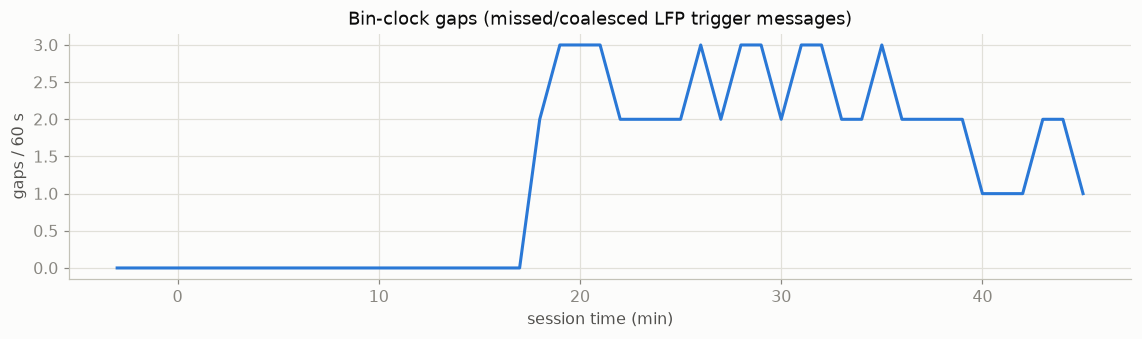

In [14]:
# bin-clock continuity
d = np.diff(rec4.timestamp.to_numpy())
gaps = d[d != TBIN]
print(f'bin steps != {TBIN} samples: {gaps.size:,} of {d.size:,} '
      f'({gaps.size/d.size*100:.3f} %); largest gap {gaps.max()/FS*1e3 if gaps.size else 0:.1f} ms')

gap_w = pd.Series((d != TBIN), index=w4.iloc[1:].to_numpy()).groupby(level=0).sum()
fig, ax = plt.subplots(figsize=(10.5, 3.2))
ax.plot(gap_w.index * WINDOW_S / 60, gap_w.values, color=PAL[0])
ax.set_xlabel('session time (min)'); ax.set_ylabel(f'gaps / {WINDOW_S} s')
ax.set_title('Bin-clock gaps (missed/coalesced LFP trigger messages)')
style_ax(ax); fig.tight_layout(); plt.show()


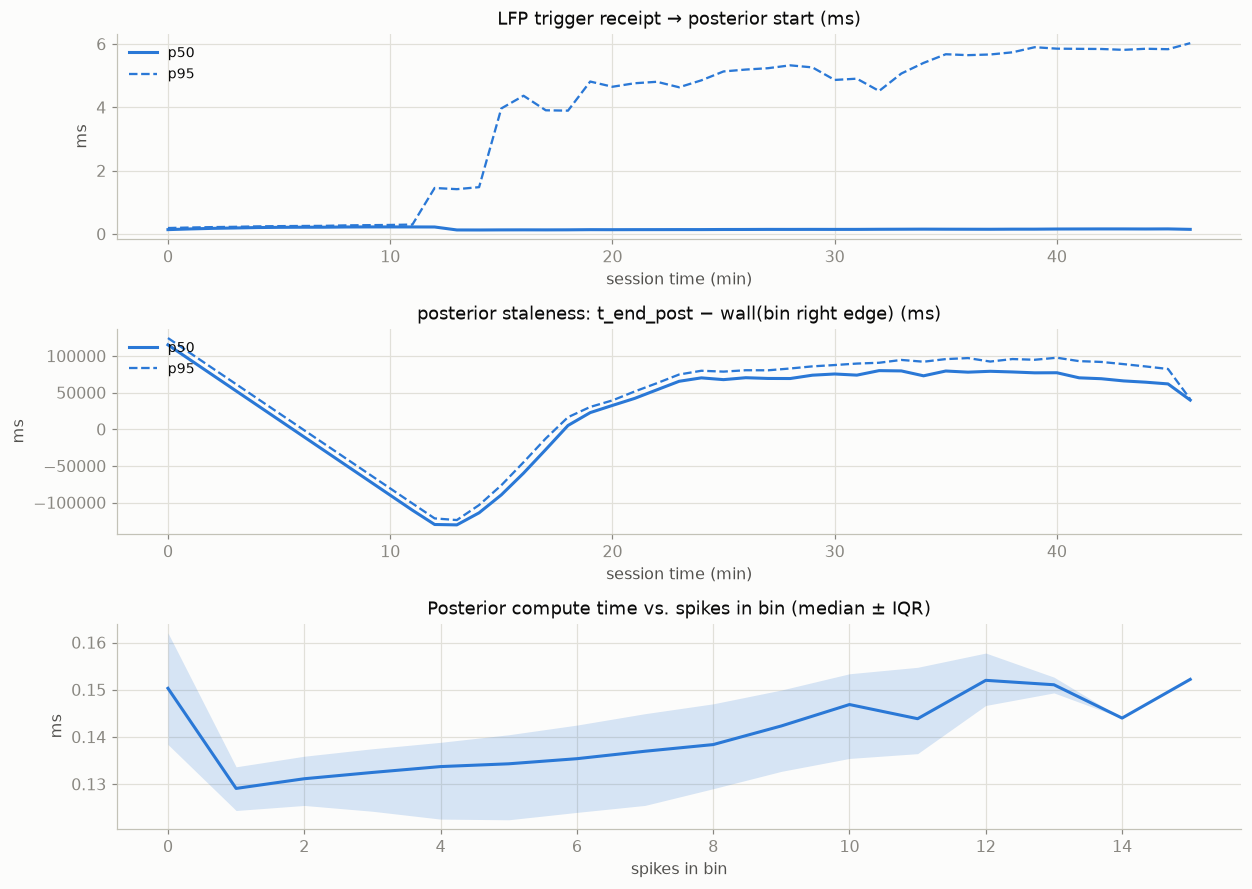

trigger→decode p50 0.19 ms, p95 1.35 ms   ·   staleness p50 14097.39 ms, p95 105084.50 ms


In [15]:
# trigger->decode latency and posterior staleness
trig_wall = pd.Series(rips.t_recv_data.to_numpy(), index=rips.timestamp.to_numpy())
trig_wall = trig_wall[~trig_wall.index.duplicated()]
trig = trig_wall.reindex(post.bin_timestamp_r.to_numpy() + DELAY).to_numpy()

lat_trig  = (post.t_start_post.to_numpy() - trig) / 1e6
staleness = (post.t_end_post.to_numpy() - wall_of_ts(post.bin_timestamp_r)) / 1e6
lat_post  = (post.t_end_post - post.t_start_post) / 1e6
pw = (t_min(post.t_end_post) * 60 // WINDOW_S).astype(int)

def wq(v, w, p):
    return pd.Series(np.asarray(v)).groupby(np.asarray(w)).quantile(p / 100)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 8.2), sharex=False)
for ax, v, name in ((axes[0], lat_trig, 'LFP trigger receipt → posterior start (ms)'),
                    (axes[1], staleness, 'posterior staleness: t_end_post − wall(bin right edge) (ms)')):
    p50, p95 = wq(v, pw, 50), wq(v, pw, 95)
    x = p50.index * WINDOW_S / 60
    ax.plot(x, p50, color=PAL[0], label='p50')
    ax.plot(x, p95, color=PAL[0], ls='--', lw=1.5, label='p95')
    ax.set_ylabel('ms'); ax.set_title(name); ax.legend(fontsize=9, loc='upper left')
    ax.set_xlabel('session time (min)')
    style_ax(ax)

gb = pd.Series(lat_post.to_numpy()).groupby(rec4.spike_count.to_numpy())
med, lo, hi = gb.median(), gb.quantile(0.25), gb.quantile(0.75)
axes[2].fill_between(med.index, lo, hi, color=PAL[0], alpha=0.18, lw=0)
axes[2].plot(med.index, med, color=PAL[0])
axes[2].set_xlabel('spikes in bin'); axes[2].set_ylabel('ms')
axes[2].set_title('Posterior compute time vs. spikes in bin (median ± IQR)')
style_ax(axes[2])
fig.tight_layout(); plt.show()

print(f'trigger→decode p50 {q(lat_trig[~np.isnan(lat_trig)],50):.2f} ms, '
      f'p95 {q(lat_trig[~np.isnan(lat_trig)],95):.2f} ms   ·   '
      f'staleness p50 {q(staleness,50):.2f} ms, p95 {q(staleness,95):.2f} ms')


## §5 — Summary

In [16]:
summary = pd.Series({
    'amplitude-qualified spikes (rec_3)':      len(rec3),
    'sent to decoder (cred_int >= 0)':         int(rec3.sent.sum()),
    'received by decoder (/spikes)':           len(spikes),
    'used in bins (sum spike_count)':          int(rec4.spike_count.sum()),
    'dropped (final counter)':                 int(rec4.dropped_spikes.iloc[-1]),
    'duplicated (final counter)':              int(rec4.duplicated_spikes.iloc[-1]),
    'drop rate (% of received)':               round(float(rec4.dropped_spikes.iloc[-1]) / len(spikes) * 100, 2),
    'late (% of bin-assigned, timing-based)':  round(sp.late.mean() * 100, 2),
    'spikes assigned to no bin':               n_unassigned,
    'added to encoding model':                 int(rec3.encode_spike.sum()),
    'decoded bins':                            len(rec4),
    'bin-clock gaps':                          int((np.diff(rec4.timestamp.to_numpy()) != TBIN).sum()),
    'KDE p50 / p95 (ms)':                      f"{q(sp.lat_kde,50):.2f} / {q(sp.lat_kde,95):.2f}",
    'end-to-end p50 / p95 (ms)':               f"{q(sp.lat_e2e,50):.2f} / {q(sp.lat_e2e,95):.2f}",
    'posterior compute p50 / p95 (ms)':        f"{q(lat_post,50):.2f} / {q(lat_post,95):.2f}",
    'posterior staleness p50 / p95 (ms)':      f"{q(staleness,50):.2f} / {q(staleness,95):.2f}",
    'KDE growth (ns per mark, per trode)':     json.dumps({t: round(s, 1) for t, s in slopes.items()}),
    'final model sizes (marks)':               json.dumps(val.reconstructed.to_dict()),
}, name=RUN_PREFIX).to_frame()

if EXPORT_CSV:
    out = os.path.join(RUN_DIR, 'performance_analysis', RUN_PREFIX + '_efficiency')
    os.makedirs(out, exist_ok=True)
    summary.to_csv(os.path.join(out, 'summary.csv'))
    wm.to_csv(os.path.join(out, 'latency_windows.csv'))
    pd.DataFrame({'window_min': dropped_w.index * WINDOW_S / 60,
                  'delta_dropped': dropped_w.values,
                  'received': recv_w.reindex(dropped_w.index).values,
                  'drop_rate_pct': rate.values}).to_csv(
        os.path.join(out, 'drop_rate_windows.csv'), index=False)
    print(f'CSVs -> {out}')
summary


CSVs -> /media/ssd1/decoder_output/Toby/20250316_07_r4/performance_analysis/20260825_193823_Toby_hex_realtime_decoding_efficiency


,20260825_193823_Toby_hex_realtime_decoding
amplitude-qualified spikes (rec_3),1422988
sent to decoder (cred_int >= 0),1319576
received by decoder (/spikes),1319569
used in bins (sum spike_count),278409
dropped (final counter),1019979
duplicated (final counter),24795
drop rate (% of received),77.3
"late (% of bin-assigned, timing-based)",28.09
spikes assigned to no bin,600076
added to encoding model,744218


## Interpretation limits

- **`rec_3` covers only amplitude-qualified spikes** (`spk_amp` gate); sub-threshold hardware
  spikes are invisible, so the true acquisition denominator is unknown. KDE-filtered spikes
  (`use_filter`: too few neighbors) get a rec_3 row (`cred_int = -1`) but **no timing row**.
- **`/spikes` is an inner join** of encoder timing with decoder receipt — sent-but-never-received
  spikes are absent from it (counted in the sanity panel).
- **"Posterior availability" is proxied by `t_end_post`**, which brackets only `compute_posterior`;
  credible-interval computation and the MPI send to supervisor/GUI (sub-ms) are not instrumented,
  and no downstream (stimulation/GUI) receive time is recorded anywhere.
- **`dropped_spikes` overcounts slightly**: the census at each 2000-message buffer wrap counts
  still-in-flight spikes (~2 bins' worth) as dropped and never corrects. The timing-based
  `late %` here is the cleaner per-spike measure; expect the two to differ modestly.
- **`delivery` latency mixes clocks** (Trodes `systemTimestamp` from the recording computer vs.
  client `time.time_ns()`) — valid only if both run on the same/synced host.
- **Sample→wall mapping** is an affine fit of `/ripples` (`timestamp`, `t_recv_data`); its residual
  (reported in the clock-fit cell) bounds the staleness measurement error. During **playback**,
  wall-clock latencies reflect playback pacing, not live acquisition.
- **Dumped spikes are never removed from the encoding clouds** — dropping affects decoding
  content only; every bin still gets a posterior (zero-spike bins use the no-spike likelihood).